<a href="https://colab.research.google.com/github/Rhuan-Messias/T-picosIA/blob/main/v1_ml_cat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt
import random

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [5]:
# Carrega o modelo pré-treinado no ImageNet
model = ResNet50(weights='imagenet')
print("Modelo ResNet50 carregado com sucesso!")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Modelo ResNet50 carregado com sucesso!


In [6]:
# Carregamos apenas 100 imagens do conjunto de treino
dataset_raw, info = tfds.load(
    'cats_vs_dogs',
    split='train[:100]',
    with_info=True,
    as_supervised=True
)

# Convertemos para uma lista para facilitar o acesso individual nas próximas células
images_list = list(dataset_raw)
print(f"Dataset carregado! {len(images_list)} imagens prontas para teste.")

Dataset carregado! 100 imagens prontas para teste.


In [12]:
def classify_dataset_image(index):
    # 1. Pegar a imagem e o label real (0=cão, 1=gato) do dataset
    img_tensor, true_label = images_list[index]
    label_name = "Gato" if true_label == 1 else "Cão"

    # 2. Redimensionar
    img_resized = tf.image.resize(img_tensor, (224, 224))

    # 3. Converter para array e FORÇAR UMA CÓPIA EDITÁVEL (.copy())
    img_array = tf.keras.preprocessing.image.img_to_array(img_resized)
    img_batch = np.expand_dims(img_array, axis=0).copy() # O .copy() resolve o erro de 'read-only'

    # 4. Pré-processamento e Predição
    img_preprocessed = preprocess_input(img_batch)
    predictions = model.predict(img_preprocessed)
    decoded = decode_predictions(predictions, top=1)[0][0]

    # 5. Lógica de identificação (Cat labels)
    cat_labels = ['tabby', 'tiger_cat', 'persian_cat', 'siamese_cat', 'egyptian_cat',
                  'lynx', 'leopard', 'jaguar', 'cheetah', 'lion', 'tiger', 'cat']

    predicted_label = decoded[1]
    score = decoded[2]
    is_cat = any(cat in predicted_label.lower() for cat in cat_labels)

    # 6. Exibição
    plt.imshow(img_tensor.numpy().astype(np.uint8))
    plt.title(f"Real: {label_name} | Predição: {predicted_label} ({score*100:.1f}%)")
    plt.axis('off')
    plt.show()

    if is_cat:
        print(f"Resultado: É um Gato!")
    else:
        print(f"Resultado: Não é um gato (ou é um cão/outro animal).")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


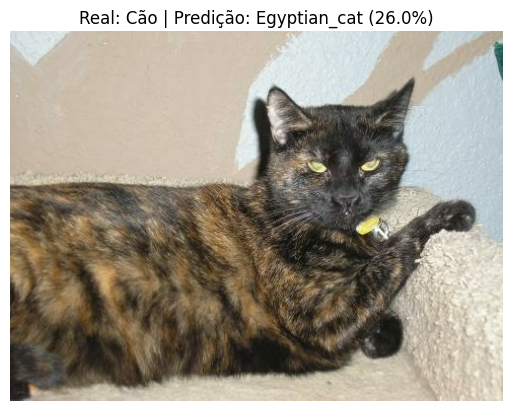

Resultado: É um Gato!


In [18]:
# Escolha um número de 0 a 99
indice_da_imagem = random.randint(1,100)

classify_dataset_image(indice_da_imagem)